<h2 align='center' style='color:blue'>Exercise: Outlier removal using standard deviation and z score<h2>

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [28]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import numpy as np # Added numpy import
import scipy.stats as st # Added scipy.stats import
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [16]:
df = pd.read_csv("/content/sample_data/bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


We will quickly examine price_per_sqft column to check min,max,mean and percentile values

In [17]:
df.price_per_sqft.describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


Above, you can see max is 12000000, which is too much price for price per sqft. Looks like this dataset has some very bad outliers so we will first remove those with percentile and then use z score

Also **plot histogram** to see how is the data distribution

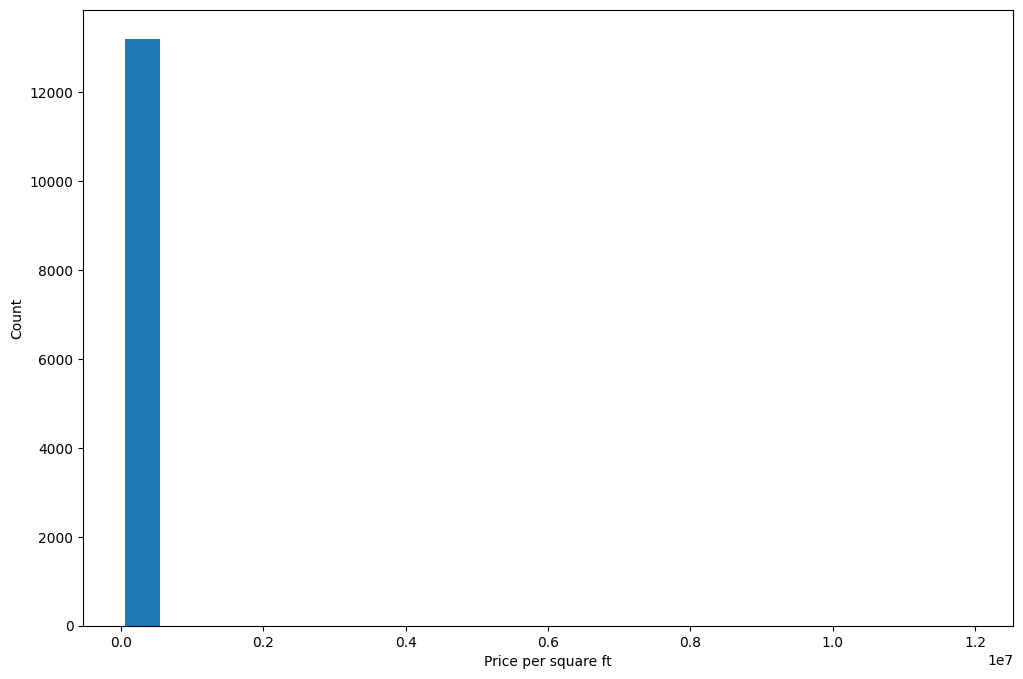

In [18]:
plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per square ft")
plt.ylabel("Count")
plt.show()

Above chart confirms our understanding that this dataset has some bad outliers. Because we see only one bar with more than 12000 data points but on the right hand side there are data points that have higher value for price per sqft but count of these data points is very tiny compared to 12000 hence we can hardly see any bar

Using **log scale** can make visualization little better

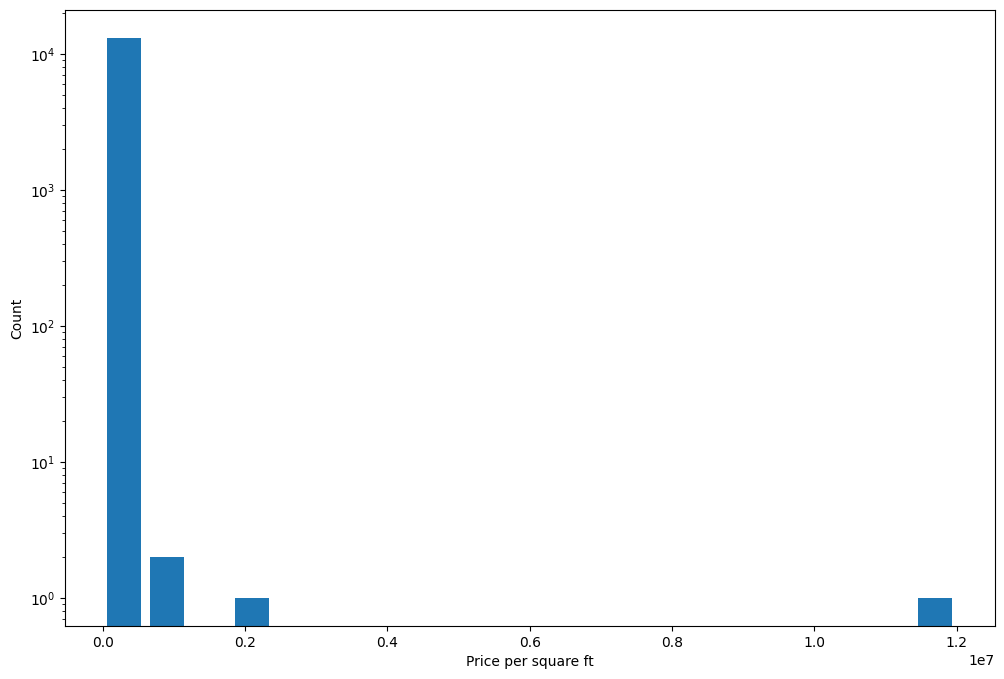

In [19]:
plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per square ft")
plt.ylabel("Count")
plt.yscale('log') # Added log scale to y-axis
plt.show()

You see atleast few bars on right hand side of our highest building at least :)

<h3 style='color:purple'>(1) Treat outliers using percentile first</h3>

In [20]:
lower_bound = df.price_per_sqft.quantile(0.001)
upper_bound = df.price_per_sqft.quantile(0.999)
print(lower_bound, upper_bound)

1366.184 50959.36200000098


In [21]:
df2 = df[(df.price_per_sqft < upper_bound) & (df.price_per_sqft > lower_bound)]
# Display the head of the new DataFrame for confirmation
df2.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [22]:
df2 = df[(df.price_per_sqft < upper_bound) & (df.price_per_sqft > lower_bound)]
df2.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274


Above shows properties that has price_per_sqft value such as 500 rs which is very very low for the city of banglore. You would be very lucky if you can find such as property :)
Also we have properties that has price per sqft value such as 12000000 which is way too high. It seems almost impossible and even if it is legitimate it can help data analysis process if we remove such a data point

In [23]:
df.shape

(13200, 7)

**We removed total 28 outliers**

<h3 style='color:purple'>(2) Now remove outliers using 4 standard deviation</h3>

In [24]:
mean = df2.price_per_sqft.mean()
std_dev = df2.price_per_sqft.std()

lower_limit = mean - 4 * std_dev
upper_limit = mean + 4 * std_dev
print(lower_limit, upper_limit)

df3 = df2[(df2.price_per_sqft < upper_limit) & (df2.price_per_sqft > lower_limit)]
df3.head(10)

-9900.429065502549 23227.73653589429


,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828
10,Whitefield,3 BHK,1800.0,2.0,70.00,3,3888


In this step we removed total 125 outliers

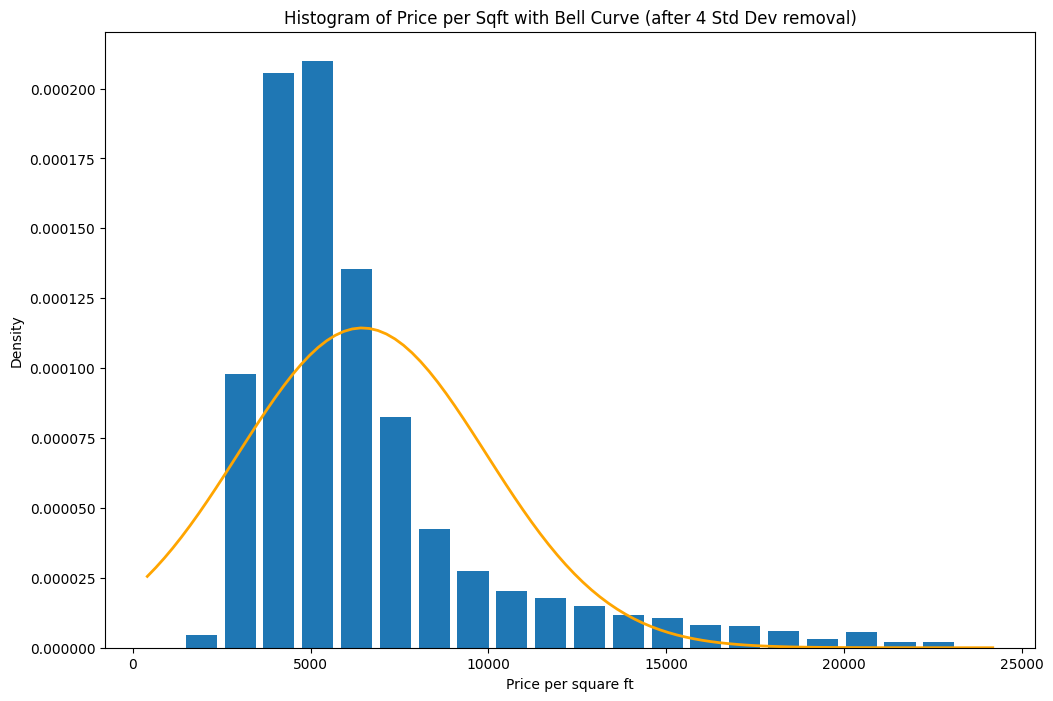

In [29]:
# Plot histogram for df3
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8, density=True) # Use density=True for PDF comparison
plt.xlabel("Price per square ft")
plt.ylabel("Density") # Changed label to density

# Plot bell curve
mean = df3.price_per_sqft.mean()
std_dev = df3.price_per_sqft.std()

# Generate points for the bell curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = st.norm.pdf(x, mean, std_dev)

plt.plot(x, p, color='orange', linewidth=2)
plt.title("Histogram of Price per Sqft with Bell Curve (after 4 Std Dev removal)")
plt.show()

<h3 style='color:purple'>(3) Now remove outliers using z score. Use z score of 4 as your thresold</h3>

In [30]:
# Calculate Z-scores for price_per_sqft in df2
df_zscore = df2.copy() # Create a copy to avoid SettingWithCopyWarning
df_zscore['zscore'] = (df_zscore.price_per_sqft - df_zscore.price_per_sqft.mean()) / df_zscore.price_per_sqft.std()

# Remove outliers where zscore > 4 or zscore < -4
df4 = df_zscore[(df_zscore.zscore < 4) & (df_zscore.zscore > -4)]
df4.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715923
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494722
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569583
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101099
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582864
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247,-0.825075
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467,0.193997
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181,2.781282
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828,-0.443285
10,Whitefield,3 BHK,1800.0,2.0,70.00,3,3888,-0.670283
